# RQ4 — Correlation

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from analysis._loader import load_all_results, success_only
from analysis._analysis import (
    setup_matplotlib, tex,
    IMG_COLS, ALL_CORRUPT_COLS,
)

setup_matplotlib()

df_all = load_all_results(include_baseline_fail=True)
df     = success_only(df_all)

# Models with enough successes for meaningful analysis
MODELS = [m for m in sorted(df.model.unique())
          if (df.model == m).sum() >= 30]

SCENE_LABEL = {
    'single/solo':  'SC-SI',
    'single/multi': 'SC-MI',
    'multi':        'MC',
}
SCENES = ['single/solo', 'single/multi', 'multi']

## Attack Distributions

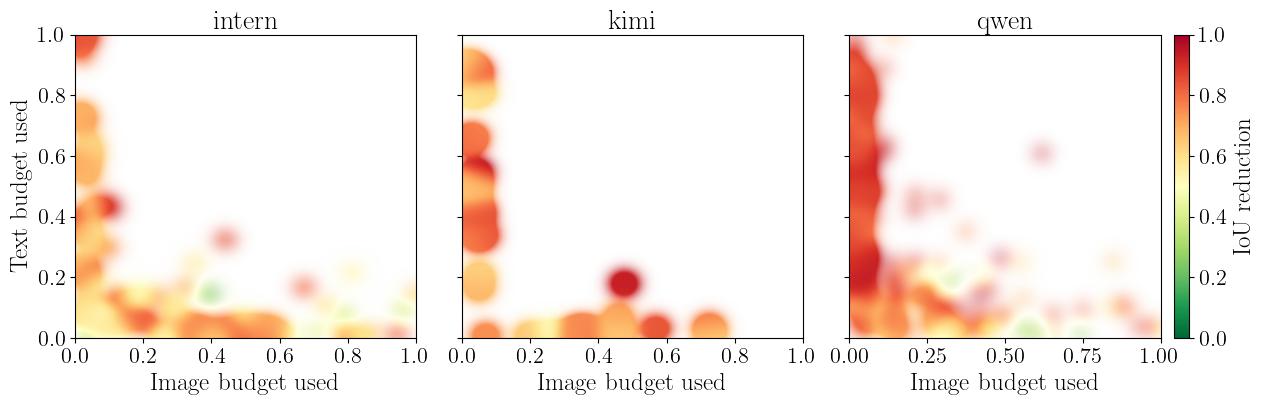

In [23]:
sub_mm = df[(df['genome_mode'] == 'multi') & df['model'].isin(MODELS)]
sub_mm = sub_mm.dropna(subset=['img_budget_used', 'txt_budget_used'])
n = len(MODELS)

GS    = 500
SIGMA = 0.03
xi    = np.linspace(0, 1, GS)
yi    = np.linspace(0, 1, GS)
gx, gy = np.meshgrid(xi, yi)

fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.0), sharey=True)
if n == 1:
    axes = [axes]
for k, (ax, model) in enumerate(zip(axes, MODELS)):
    sub = sub_mm[sub_mm['model'] == model]
    px  = sub['img_budget_used'].values
    py  = sub['txt_budget_used'].values
    val = sub['iou_reduction'].values

    weighted_sum = np.zeros((GS, GS))
    weight_total = np.zeros((GS, GS))
    for xp, yp, v in zip(px, py, val):
        w = np.exp(-((gx - xp)**2 + (gy - yp)**2) / (2 * SIGMA**2))
        weighted_sum += w * v
        weight_total += w

    color = np.where(weight_total > 0, weighted_sum / weight_total, 0.0)
    pos_w = weight_total[weight_total > 0]
    alpha = np.clip(weight_total / np.percentile(pos_w, 90), 0, 1)

    norm = plt.Normalize(vmin=0, vmax=1)
    rgba = plt.cm.RdYlGn_r(norm(color))
    rgba[..., 3] = alpha

    ax.imshow(rgba, origin='lower', extent=[0, 1, 0, 1], aspect='auto')
    sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
    sm.set_array([])
    ax.set_xlabel('Image budget used')
    if k == 0:
        ax.set_ylabel('Text budget used')
    ax.set_title(tex(model), pad=3)

cbar = plt.colorbar(sm, ax=axes[-1], fraction=0.046, pad=0.04)
cbar.set_label('IoU reduction')
plt.tight_layout(pad=0.3)
plt.savefig('figures/rq4_budget_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()

 ## Modality Sensitivity

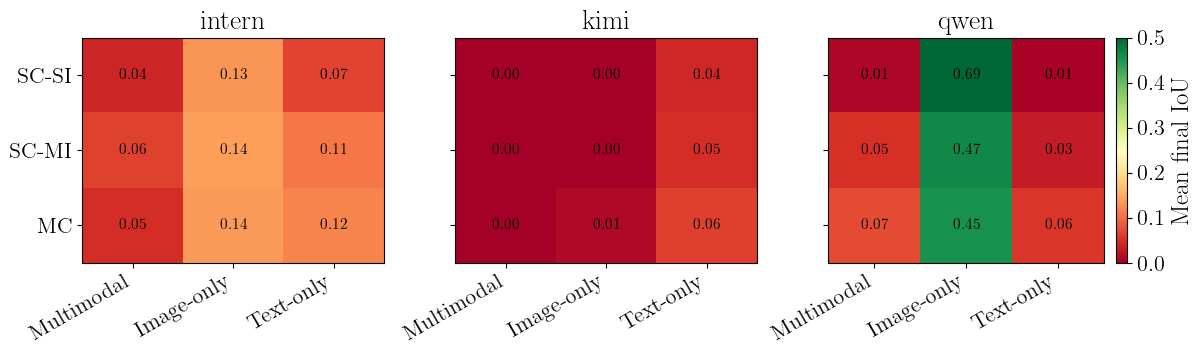

In [24]:
GMODES      = ['multi', 'image', 'text']
GMODE_LABEL = {'multi': 'Multimodal', 'image': 'Image-only', 'text': 'Text-only'}
n = len(MODELS)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5), sharey=True)
if n == 1:
    axes = [axes]
for k, (ax, model) in enumerate(zip(axes, MODELS)):
    matrix = np.full((len(SCENES), len(GMODES)), np.nan)
    for i, scene in enumerate(SCENES):
        for j, gmode in enumerate(GMODES):
            sub = df[(df.model == model) & (df.obj_category == scene)
                     & (df.genome_mode == gmode)]
            if len(sub) >= 3:
                matrix[i, j] = sub['final_iou'].mean()

    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=0.5, aspect='auto')
    if k==0:
            ax.set_yticks(range(len(SCENES)))
            ax.set_yticklabels([SCENE_LABEL[s] for s in SCENES])
    ax.set_xticks(range(len(GMODES)))
    ax.set_xticklabels([GMODE_LABEL[g] for g in GMODES], rotation=30, ha='right')
    ax.set_title(tex(model))
    for i in range(len(SCENES)):
        for j in range(len(GMODES)):
            if not np.isnan(matrix[i, j]):
                ax.text(j, i, f'{matrix[i,j]:.2f}', ha='center', va='center',
                        fontsize=11, color='k', fontweight='bold')
else:
    plt.colorbar(im, ax=ax, label='Mean final IoU', fraction=0.046, pad=0.04)

plt.tight_layout(pad=0.3)
plt.savefig('figures/rq4_scene_modality_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Corruption Fingerprints of Successful Attacks

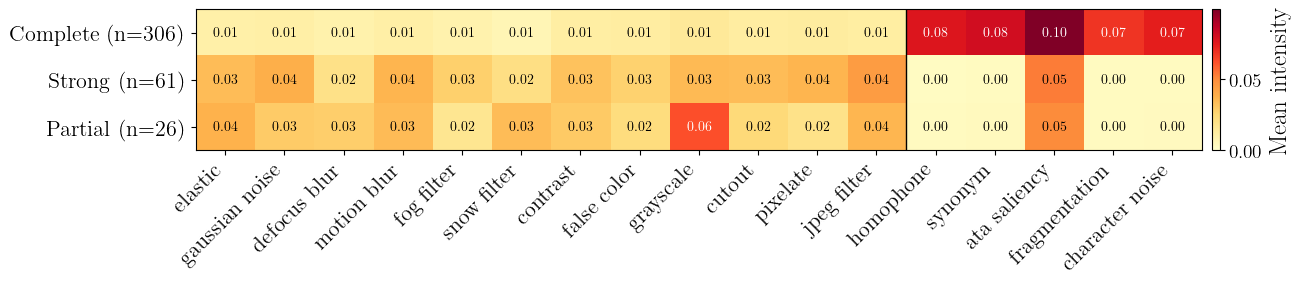

In [25]:
sub = df[df['genome_mode'] == 'multi'].copy()
sub['outcome'] = pd.cut(sub['final_iou'],
                         bins=[-0.001, 0.001, 0.25, 1.0],
                         labels=['Complete', 'Strong', 'Partial'])

xlabels = [tex(c.removeprefix('img_').removeprefix('txt_')) for c in ALL_CORRUPT_COLS]
outcomes = ['Complete', 'Strong', 'Partial']

matrix = np.array([
    [sub[sub['outcome'] == o][c].mean() for c in ALL_CORRUPT_COLS]
    for o in outcomes
])
counts = {o: (sub['outcome'] == o).sum() for o in outcomes}

fig, ax = plt.subplots(figsize=(13, 2.8))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=matrix.max())
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels(xlabels, rotation=45, ha='right')
ax.set_yticks(range(len(outcomes)))
ax.set_yticklabels([f'{o}  (n={counts[o]})' for o in outcomes])
ax.axvline(len(IMG_COLS) - 0.5, color='black', lw=1)
for i in range(len(outcomes)):
    for j in range(len(ALL_CORRUPT_COLS)):
        v = matrix[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=10, color='k' if v < matrix.max() * 0.6 else 'w')
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('Mean intensity')
cbar.ax.tick_params(labelsize=14)
plt.tight_layout(pad=0.3)
plt.savefig('figures/rq4_corruption_fingerprints.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Success Attribution

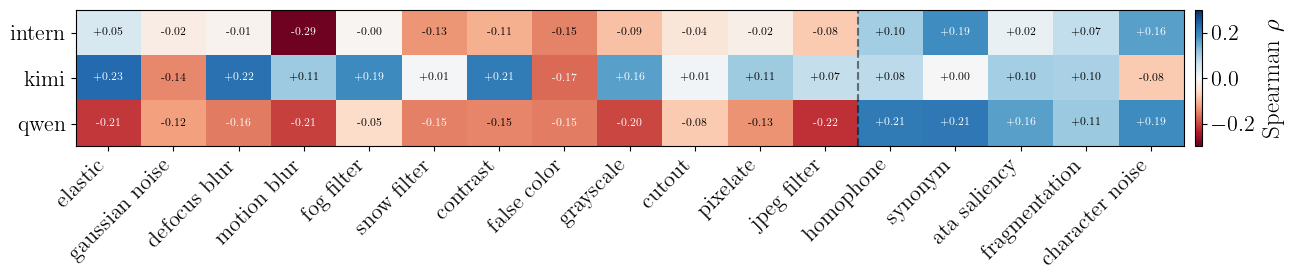

In [26]:
from scipy import stats as scipy_stats

sub_mm  = df[df['genome_mode'] == 'multi']
xlabels = [tex(c.removeprefix('img_').removeprefix('txt_')) for c in ALL_CORRUPT_COLS]


def _metric_matrix(metric_fn):
    rows = {}
    for model in MODELS:
        sub = sub_mm[sub_mm['model'] == model]
        if len(sub) < 10:
            continue
        rows[tex(model)] = [metric_fn(sub, c) for c in ALL_CORRUPT_COLS]
    mat = pd.DataFrame(rows, index=ALL_CORRUPT_COLS).T
    mat.columns = xlabels
    return mat.values, list(rows.keys())


def spearman_fn(sub, c):
    return scipy_stats.spearmanr(sub['iou_reduction'], sub[c])[0]

fig,ax = plt.subplots(1,1,figsize=(13, 2.8))
vals, model_names = _metric_matrix(spearman_fn)
im = ax.imshow(vals, cmap='RdBu', vmin=-0.3, vmax=0.3, aspect='auto')
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels(xlabels, rotation=45, ha='right')
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names)
ax.axvline(len(IMG_COLS) - 0.5, color='k', lw=1.5, ls='--', alpha=0.5)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v = vals[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    fontsize=8, color='k' if abs(v) < abs(0.3) * 0.5 else 'w')
cbar = plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cbar.set_label('Spearman $\\rho$')

plt.tight_layout(pad=0.4)
plt.savefig('figures/rq4_corruption_attribution.pdf', dpi=150, bbox_inches='tight')
plt.show()